MADE BY MAHTAB UDDIN AHMED

# BadODD — Full Kaggle Implementation Notebook
[
This notebook is designed for the dataset archive named **`badodd.zip`**.

It reproduces the main training settings reported in the paper as closely as possible:

- Images: 9,825
- Classes: 13
- Train/Validation/Test: 5,896 / 1,964 / 1,965
- Image size: 416 × 416
- Batch size: 64
- Learning rate: 0.001
- Optimizer: Adam
- Weight decay: 1e-4
- Epochs: 10

The paper reports mAP ≈ 0.60 for YOLOv5 and ≈ 0.70 for YOLOv8.

**Important:** the paper does not specify the exact YOLO model size (n/s/m/l/x), random seed,
pretrained checkpoint, augmentation settings, or exact mAP convention. This notebook uses
YOLOv5s and YOLOv8s as practical reproducible baselines and seed 42.

## Before running

1. Upload your Kaggle Dataset containing **`badodd.zip`**.
2. Add that dataset to this notebook using **Add Input**.
3. In Kaggle Notebook settings, enable a GPU.
4. If installation or GitHub cloning fails, enable **Internet** in Kaggle notebook settings.
5. Run cells from top to bottom.

In [26]:
# Cell 1 — Basic environment check
import sys
import os
from pathlib import Path
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. Turn on GPU in Kaggle settings.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [27]:
# Cell 2 — Reproducibility seed
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [28]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

if not INPUT_ROOT.exists():
    raise FileNotFoundError("/kaggle/input does not exist.")

all_files = [p for p in INPUT_ROOT.rglob("*") if p.is_file()]

print("Total files found:", len(all_files))

print("\nTop-level Kaggle inputs:")
for p in INPUT_ROOT.iterdir():
    print(" -", p)

# Search ZIP files case-insensitively
zip_files = [
    p for p in all_files
    if p.suffix.lower() == ".zip"
]

print("\nZIP files found:")
for z in zip_files:
    print(" -", z)

# Prefer badodd.zip specifically
badodd_zips = [
    p for p in zip_files
    if p.name.lower() == "badodd.zip"
]

if badodd_zips:
    BADODD_ZIP = badodd_zips[0]
    DATA_ALREADY_EXTRACTED = False

    print("\nUsing BadODD ZIP:")
    print(BADODD_ZIP)

elif len(zip_files) == 1:
    # If only one ZIP exists, use it even if its filename differs
    BADODD_ZIP = zip_files[0]
    DATA_ALREADY_EXTRACTED = False

    print("\nExact badodd.zip not found.")
    print("But one ZIP file was found, so using:")
    print(BADODD_ZIP)

else:
    BADODD_ZIP = None
    DATA_ALREADY_EXTRACTED = True

    print("\nNo ZIP file found.")
    print("Kaggle may already have the BadODD files extracted.")

Total files found: 20074

Top-level Kaggle inputs:
 - /kaggle/input/datasets

ZIP files found:

No ZIP file found.
Kaggle may already have the BadODD files extracted.


In [29]:
import zipfile
import shutil
from pathlib import Path

if not DATA_ALREADY_EXTRACTED:

    EXTRACT_DIR = Path("/kaggle/working/badodd_raw")

    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting:")
    print(BADODD_ZIP)

    with zipfile.ZipFile(BADODD_ZIP, "r") as z:
        z.extractall(EXTRACT_DIR)

    ROOT = EXTRACT_DIR

    print("\nExtraction completed.")
    print("Dataset root:", ROOT)

else:

    # Dataset appears already extracted in Kaggle Input
    ROOT = INPUT_ROOT

    print("Using already-mounted/extracted Kaggle dataset.")
    print("Dataset root:", ROOT)

Using already-mounted/extracted Kaggle dataset.
Dataset root: /kaggle/input


In [30]:
# Cell 5 — Inspect the dataset folder structure

from pathlib import Path

# ROOT should already be created in Cell 4
if "ROOT" not in globals():
    raise NameError(
        "ROOT is not defined. Please run Cell 3 and Cell 4 first."
    )

print("Dataset root:")
print(ROOT)

print("\nChecking dataset files...\n")

all_items = list(Path(ROOT).rglob("*"))

print("Total dataset items found:", len(all_items))

print("\nFirst 120 files/folders:\n")

for p in all_items[:120]:
    print(p)

Dataset root:
/kaggle/input

Checking dataset files...

Total dataset items found: 20088

First 120 files/folders:

/kaggle/input/datasets
/kaggle/input/datasets/mahtabuddinahmed
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/banglatesla.names
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/val
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/train
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/val/labels
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/val/labels.cache
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/val/images
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels.cache
/kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images
/kaggle/input/datasets/ma

In [31]:
# Cell 6 — Count images and text annotation files
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = sorted([
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

all_txt_files = sorted([
    p for p in ROOT.rglob("*.txt")
    if p.is_file()
])

print("Images found:", len(images))
print("All TXT files found:", len(all_txt_files))

print("\nSample images:")
for p in images[:10]:
    print(" ", p)

print("\nSample TXT files:")
for p in all_txt_files[:10]:
    print(" ", p)

Images found: 10038
All TXT files found: 10032

Sample images:
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/._maowa_expressway3_3068.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/.ipynb_checkpoints/chittagong_bohoddarhat1_10384-checkpoint.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/chittagong_bohoddarhat1_10384.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/chittagong_bohoddarhat1_10797.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/chittagong_bohoddarhat1_11033.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/chittagong_bohoddarhat1_11151.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/chittagong_bohoddarhat1_11210.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/chittagong_bohoddarhat1_11269.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test

In [32]:
# Cell 7 — Show possible dataset split directories
candidate_split_dirs = []

for p in ROOT.rglob("*"):
    if p.is_dir() and p.name.lower() in {"train", "val", "valid", "validation", "test"}:
        candidate_split_dirs.append(p)

print("Possible split directories:")
for p in candidate_split_dirs:
    print(" -", p)

Possible split directories:
 - /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/val
 - /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test
 - /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/train


## Class names

The notebook uses the 13 BadODD object categories in this order.

If the archive itself contains an official class-name file, the next cells will print it so you can verify the order.

In [33]:
# Cell 8 — Look for likely class-name files inside the archive
name_file_candidates = []

for p in all_txt_files:
    n = p.name.lower()
    if any(k in n for k in ["name", "class", "obj"]):
        name_file_candidates.append(p)

print("Possible class-name files:")
for p in name_file_candidates[:30]:
    print("\nFILE:", p)
    try:
        print(p.read_text(errors="ignore")[:2000])
    except Exception as e:
        print("Could not read:", e)

Possible class-name files:


In [34]:
# Cell 9 — Define the 13 class names used by this notebook
names = {
    0: "auto_rickshaw",
    1: "bicycle",
    2: "bus",
    3: "car",
    4: "cart_vehicle",
    5: "construction_vehicle",
    6: "motorbike",
    7: "person",
    8: "priority_vehicle",
    9: "three_wheeler",
    10: "train",
    11: "truck",
    12: "wheelchair",
}

class_names = list(names.values())

print("Classes:")
for k, v in names.items():
    print(k, "->", v)

Classes:
0 -> auto_rickshaw
1 -> bicycle
2 -> bus
3 -> car
4 -> cart_vehicle
5 -> construction_vehicle
6 -> motorbike
7 -> person
8 -> priority_vehicle
9 -> three_wheeler
10 -> train
11 -> truck
12 -> wheelchair


In [35]:
# Cell 10 — Inspect sample TXT contents to verify annotation format
# We exclude obvious class-name/config files when possible.
annotation_candidates = []

for p in all_txt_files:
    n = p.name.lower()
    if any(k in n for k in ["names", "classes", "obj.data", "train.txt", "test.txt", "valid.txt", "val.txt"]):
        continue
    annotation_candidates.append(p)

print("Showing up to 12 annotation-like TXT files:\n")

for label_file in annotation_candidates[:12]:
    print("\nFILE:", label_file)
    try:
        print(label_file.read_text(errors="ignore")[:700])
    except Exception as e:
        print("ERROR:", e)

Showing up to 12 annotation-like TXT files:


FILE: /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_10384.txt
11 0.5653645833333334 0.6708333333333334 0.6598958333333333 0.6583333333333333
3 0.11588541666666667 0.6912037037037038 0.23177083333333334 0.5824074074074074
7 0.20364583333333333 0.5481481481481482 0.028125 0.044444444444444446


FILE: /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_10797.txt
11 0.5377604166666666 0.7037037037037037 0.5921875 0.5925925925925926
3 0.12864583333333332 0.675 0.25729166666666664 0.3907407407407407


FILE: /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11033.txt
7 0.13567708333333334 0.7189814814814814 0.025520833333333333 0.16574074074074074
9 0.026041666666666668 0.7939814814814814 0.052083333333333336 0.20277777777777778
2 0.2833333333333333 0.6287037037037037 0.23645833333333333 0.387037037037037
0 0.44375 

In [36]:
# Cell 11 — Helper: test whether a TXT file looks like YOLO detection labels
def looks_like_yolo_label(path, max_lines=30):
    try:
        lines = path.read_text(errors="ignore").strip().splitlines()
    except Exception:
        return False

    if not lines:
        # Empty label files can be valid for images with no objects
        return True

    checked = 0
    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        if len(parts) != 5:
            return False

        try:
            cls = int(float(parts[0]))
            vals = list(map(float, parts[1:]))
        except Exception:
            return False

        if cls < 0:
            return False

        # Standard normalized YOLO labels usually use 0..1 for box coords.
        if any(v < 0 or v > 1 for v in vals):
            return False

        checked += 1
        if checked >= max_lines:
            break

    return True


yolo_like_txt = [p for p in annotation_candidates if looks_like_yolo_label(p)]

print("YOLO-like label files found:", len(yolo_like_txt))
print("First 10:")
for p in yolo_like_txt[:10]:
    print(" ", p)

YOLO-like label files found: 10031
First 10:
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_10384.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_10797.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11033.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11151.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11210.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11269.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11446.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11859.txt
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/labels/chittagong_bohoddarhat1_11977.txt
 

## Detect whether the archive already has train / val / test splits

If a valid original split is clearly present, preserving it is preferable.

If the archive does not expose a usable split, this notebook creates a deterministic 60/20/20 split with exact paper counts:
5,896 / 1,964 / 1,965 using seed 42.

In [37]:
# Cell 12 — Build image and label lookup tables by relative stem/name
from collections import defaultdict

labels_by_stem = defaultdict(list)
for label in yolo_like_txt:
    labels_by_stem[label.stem].append(label)

pairs = []
missing_labels = []
ambiguous_labels = []

for image in images:
    candidates = labels_by_stem.get(image.stem, [])
    if len(candidates) == 1:
        pairs.append((image, candidates[0]))
    elif len(candidates) == 0:
        missing_labels.append(image)
    else:
        # Prefer a label whose nearby folder path resembles the image path.
        image_parts = set(part.lower() for part in image.parts)
        scored = []
        for c in candidates:
            c_parts = set(part.lower() for part in c.parts)
            score = len(image_parts & c_parts)
            scored.append((score, c))
        scored.sort(key=lambda x: x[0], reverse=True)

        if len(scored) == 1 or scored[0][0] > scored[1][0]:
            pairs.append((image, scored[0][1]))
        else:
            ambiguous_labels.append((image, candidates))

print("Matched image/label pairs:", len(pairs))
print("Images without matched labels:", len(missing_labels))
print("Images with ambiguous labels:", len(ambiguous_labels))

if missing_labels[:10]:
    print("\nFirst missing-label images:")
    for p in missing_labels[:10]:
        print(" ", p)

if ambiguous_labels[:5]:
    print("\nFirst ambiguous cases:")
    for img, labs in ambiguous_labels[:5]:
        print("IMAGE:", img)
        for lab in labs:
            print("  LABEL:", lab)

Matched image/label pairs: 10031
Images without matched labels: 7
Images with ambiguous labels: 0

First missing-label images:
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/._maowa_expressway3_3068.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/.ipynb_checkpoints/chittagong_bohoddarhat1_10384-checkpoint.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/test/images/khulna6_6360.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/train/images/._chittagong_night1_21240.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/train/images/._dhaka3_5280.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/train/images/._maowa_expressway1_1947.jpg
  /kaggle/input/datasets/mahtabuddinahmed/badodd-zip/badodd/train/images/._sylhet4_0.jpg


In [38]:
# Cell 13 — Check if matched pairs appear to already belong to train/val/test folders
def infer_split_from_path(path):
    parts = [p.lower() for p in path.parts]

    if "train" in parts:
        return "train"
    if "test" in parts:
        return "test"
    if "val" in parts or "valid" in parts or "validation" in parts:
        return "val"
    return None

existing_split_pairs = {"train": [], "val": [], "test": []}
unsplit_pairs = []

for img, lab in pairs:
    s_img = infer_split_from_path(img)
    s_lab = infer_split_from_path(lab)

    # If either clearly indicates a split, use it if there is no conflict.
    split = s_img or s_lab

    if s_img and s_lab and s_img != s_lab:
        unsplit_pairs.append((img, lab))
    elif split in existing_split_pairs:
        existing_split_pairs[split].append((img, lab))
    else:
        unsplit_pairs.append((img, lab))

print("Detected existing split counts:")
for split in ["train", "val", "test"]:
    print(split, "=", len(existing_split_pairs[split]))

print("Unsplit/unresolved pairs =", len(unsplit_pairs))

Detected existing split counts:
train = 5967
val = 2032
test = 2032
Unsplit/unresolved pairs = 0


In [39]:
# Cell 14 — Decide whether to preserve existing split or create a deterministic paper-style split
EXPECTED_TOTAL = 9825
EXPECTED_COUNTS = {"train": 5896, "val": 1964, "test": 1965}

existing_total = sum(len(v) for v in existing_split_pairs.values())

USE_EXISTING_SPLIT = (
    existing_total == len(pairs)
    and len(unsplit_pairs) == 0
    and all(len(existing_split_pairs[k]) > 0 for k in ["train", "val", "test"])
)

print("USE_EXISTING_SPLIT =", USE_EXISTING_SPLIT)

if USE_EXISTING_SPLIT:
    train_pairs = existing_split_pairs["train"]
    val_pairs = existing_split_pairs["val"]
    test_pairs = existing_split_pairs["test"]

    print("\nPreserving split found inside the archive:")
    print("Train:", len(train_pairs))
    print("Val  :", len(val_pairs))
    print("Test :", len(test_pairs))
else:
    print("\nNo complete usable original split was detected.")
    print("Creating deterministic split with seed", SEED)

    pairs_for_split = pairs.copy()
    random.Random(SEED).shuffle(pairs_for_split)

    if len(pairs_for_split) < EXPECTED_TOTAL:
        print(
            f"WARNING: Paper reports {EXPECTED_TOTAL} images, "
            f"but only {len(pairs_for_split)} matched image-label pairs were found."
        )

    if len(pairs_for_split) == EXPECTED_TOTAL:
        train_pairs = pairs_for_split[:5896]
        val_pairs = pairs_for_split[5896:5896 + 1964]
        test_pairs = pairs_for_split[5896 + 1964:]
    else:
        # Safe fallback to 60/20/20 when archive count differs
        n = len(pairs_for_split)
        n_train = int(round(n * 0.60))
        n_val = int(round(n * 0.20))
        train_pairs = pairs_for_split[:n_train]
        val_pairs = pairs_for_split[n_train:n_train + n_val]
        test_pairs = pairs_for_split[n_train + n_val:]

    print("Train:", len(train_pairs))
    print("Val  :", len(val_pairs))
    print("Test :", len(test_pairs))

USE_EXISTING_SPLIT = True

Preserving split found inside the archive:
Train: 5967
Val  : 2032
Test : 2032


In [40]:
# Cell 15 — Create clean YOLO folder structure in /kaggle/working
OUTPUT = Path("/kaggle/working/badodd_yolo")

if OUTPUT.exists():
    shutil.rmtree(OUTPUT)

for split in ["train", "val", "test"]:
    (OUTPUT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Created:", OUTPUT)

Created: /kaggle/working/badodd_yolo


In [41]:
# Cell 16 — Copy matched image/label pairs into YOLO structure
# Duplicate filenames are made unique if necessary.

def safe_copy_pairs(pair_list, split):
    img_dir = OUTPUT / "images" / split
    lbl_dir = OUTPUT / "labels" / split

    used_names = set()

    for i, (image_path, label_path) in enumerate(pair_list):
        base_stem = image_path.stem
        img_suffix = image_path.suffix.lower()

        stem = base_stem
        counter = 1

        while (stem + img_suffix) in used_names or (img_dir / (stem + img_suffix)).exists():
            stem = f"{base_stem}_{counter}"
            counter += 1

        used_names.add(stem + img_suffix)

        image_destination = img_dir / f"{stem}{img_suffix}"
        label_destination = lbl_dir / f"{stem}.txt"

        shutil.copy2(image_path, image_destination)
        shutil.copy2(label_path, label_destination)


safe_copy_pairs(train_pairs, "train")
safe_copy_pairs(val_pairs, "val")
safe_copy_pairs(test_pairs, "test")

print("Copy complete.")

Copy complete.


In [42]:
# Cell 17 — Verify final dataset counts
def count_images(folder):
    return sum(
        1 for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

for split in ["train", "val", "test"]:
    n_images = count_images(OUTPUT / "images" / split)
    n_labels = len(list((OUTPUT / "labels" / split).glob("*.txt")))

    print(f"{split:5s} | images = {n_images:5d} | labels = {n_labels:5d}")

train | images =  5967 | labels =  5967
val   | images =  2032 | labels =  2032
test  | images =  2032 | labels =  2032


In [43]:
# Cell 18 — Validate YOLO label values
label_problems = []
class_counts = {i: 0 for i in names}

for split in ["train", "val", "test"]:
    for label_path in (OUTPUT / "labels" / split).glob("*.txt"):
        text = label_path.read_text(errors="ignore").strip()

        if not text:
            continue

        for line_no, line in enumerate(text.splitlines(), start=1):
            parts = line.strip().split()

            if len(parts) != 5:
                label_problems.append((label_path, line_no, "not 5 columns", line))
                continue

            try:
                cls = int(float(parts[0]))
                xc, yc, bw, bh = map(float, parts[1:])
            except Exception:
                label_problems.append((label_path, line_no, "parse error", line))
                continue

            if cls not in names:
                label_problems.append((label_path, line_no, f"invalid class {cls}", line))
                continue

            class_counts[cls] += 1

            if not all(0 <= v <= 1 for v in [xc, yc, bw, bh]):
                label_problems.append((label_path, line_no, "coordinate outside 0..1", line))

print("Label problems found:", len(label_problems))

for problem in label_problems[:20]:
    print(problem)

print("\nObject counts by class:")
for cls, count in class_counts.items():
    print(f"{cls:2d} {names[cls]:24s} {count}")

Label problems found: 0

Object counts by class:
 0 auto_rickshaw            17816
 1 bicycle                  1195
 2 bus                      3096
 3 car                      6336
 4 cart_vehicle             238
 5 construction_vehicle     41
 6 motorbike                6272
 7 person                   31016
 8 priority_vehicle         369
 9 three_wheeler            9664
10 train                    42
11 truck                    3863
12 wheelchair               84


In [44]:
# Cell 19 — Create badodd.yaml
import yaml

data_config = {
    "path": str(OUTPUT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names,
}

YAML_PATH = Path("/kaggle/working/badodd.yaml")

with open(YAML_PATH, "w") as f:
    yaml.safe_dump(data_config, f, sort_keys=False)

print(YAML_PATH.read_text())

path: /kaggle/working/badodd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: auto_rickshaw
  1: bicycle
  2: bus
  3: car
  4: cart_vehicle
  5: construction_vehicle
  6: motorbike
  7: person
  8: priority_vehicle
  9: three_wheeler
  10: train
  11: truck
  12: wheelchair



## Visual annotation check

The next two cells do **not train the model**. They only verify that the boxes and class labels line up with the actual objects.

In [45]:
# Cell 20 — Function to visualize YOLO bounding boxes
import cv2
import matplotlib.pyplot as plt

def show_yolo_image(image_path, label_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    lines = Path(label_path).read_text(errors="ignore").strip().splitlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:])

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), 2)

        label_text = names.get(class_id, f"class_{class_id}")

        cv2.putText(
            image,
            label_text,
            (max(0, x1), max(20, y1)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(14, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

Image: /kaggle/working/badodd_yolo/images/train/dhaka_night3_22184.jpg
Label: /kaggle/working/badodd_yolo/labels/train/dhaka_night3_22184.txt


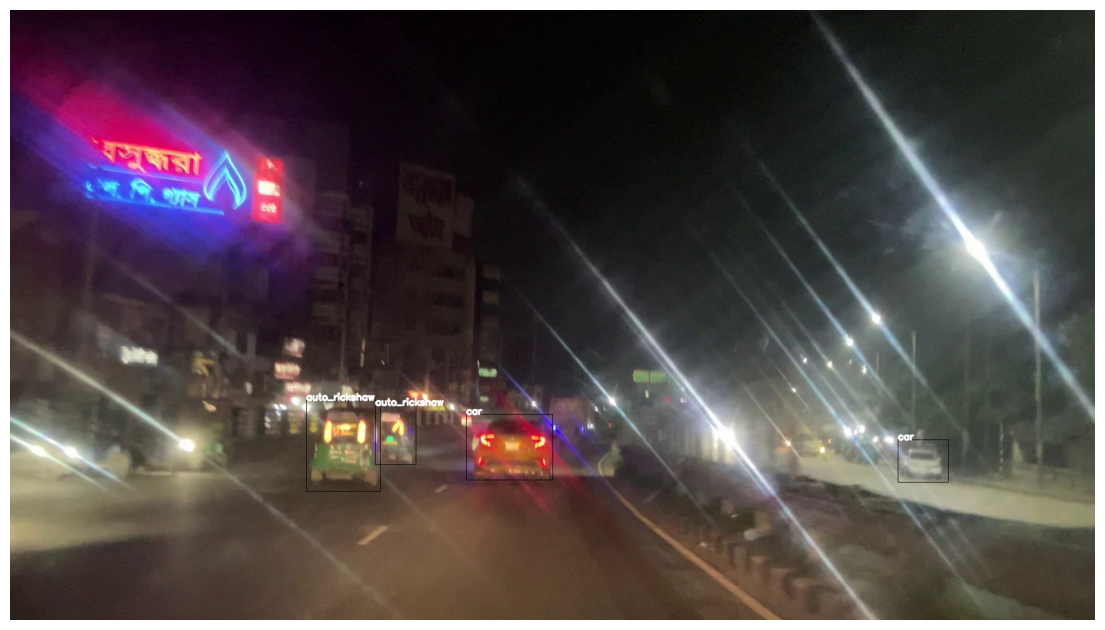

In [46]:
# Cell 21 — Display one random training image with ground-truth boxes
train_images = [
    p for p in (OUTPUT / "images" / "train").iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

img = random.choice(train_images)
lbl = OUTPUT / "labels" / "train" / f"{img.stem}.txt"

print("Image:", img)
print("Label:", lbl)

show_yolo_image(img, lbl)


Image: sylhet2_16579.jpg
Label: sylhet2_16579.txt


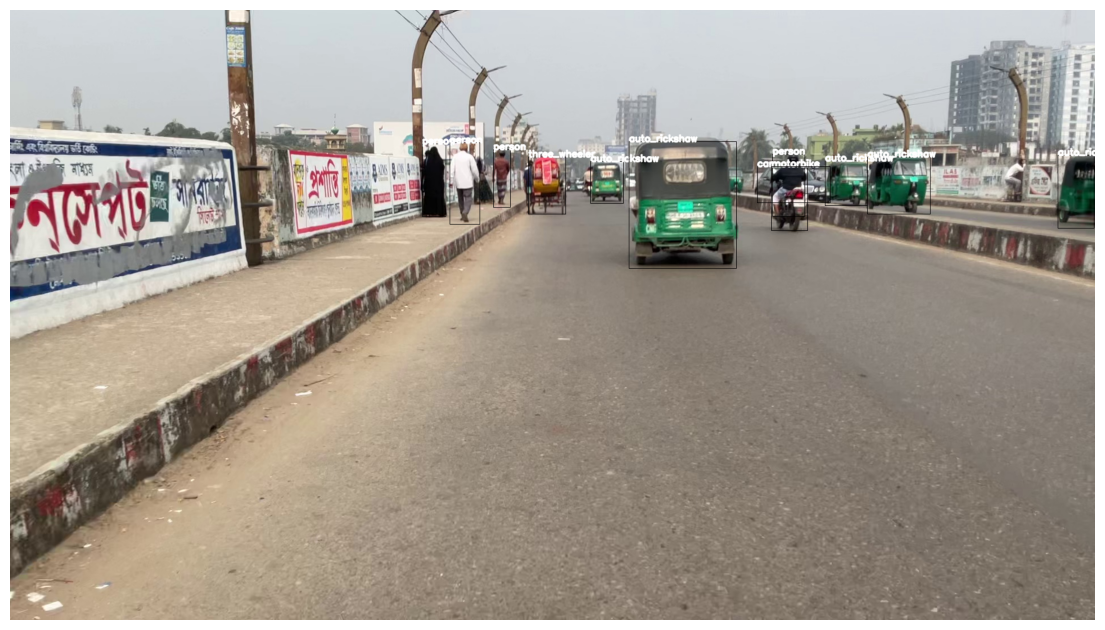


Image: dhaka_night3_44427.jpg
Label: dhaka_night3_44427.txt


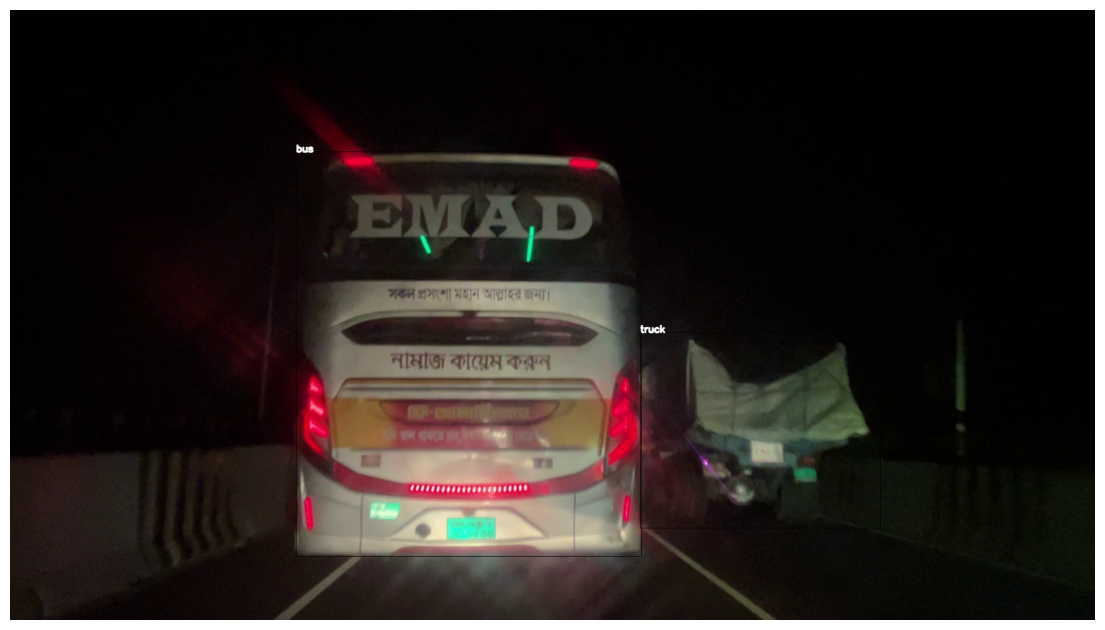


Image: chuadanga_sirajganj1_4740.jpg
Label: chuadanga_sirajganj1_4740.txt


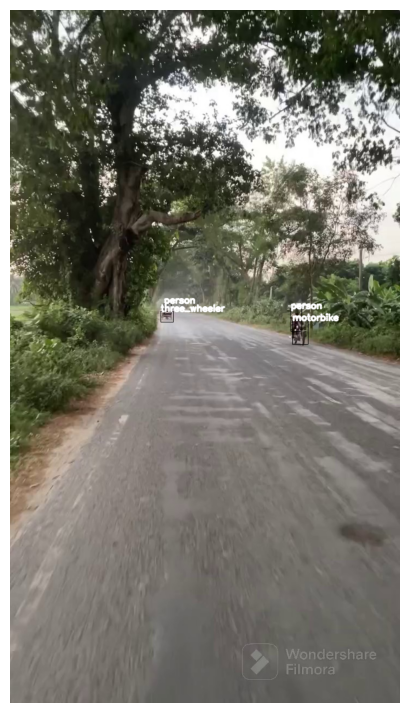


Image: khulna6_6510.jpg
Label: khulna6_6510.txt


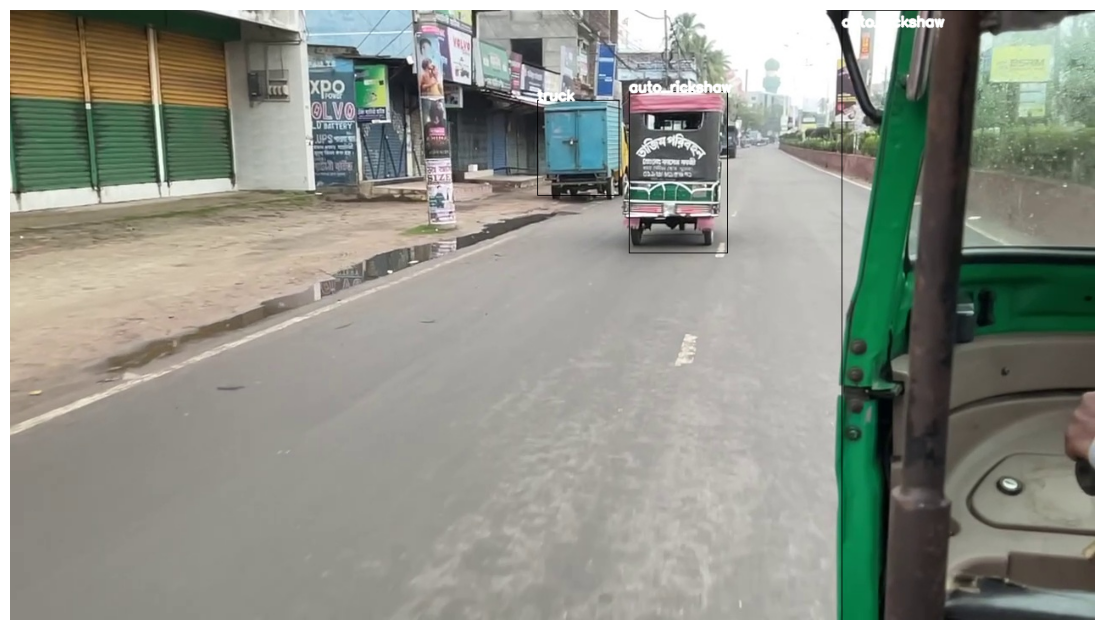


Image: sylhet4_32391.jpg
Label: sylhet4_32391.txt


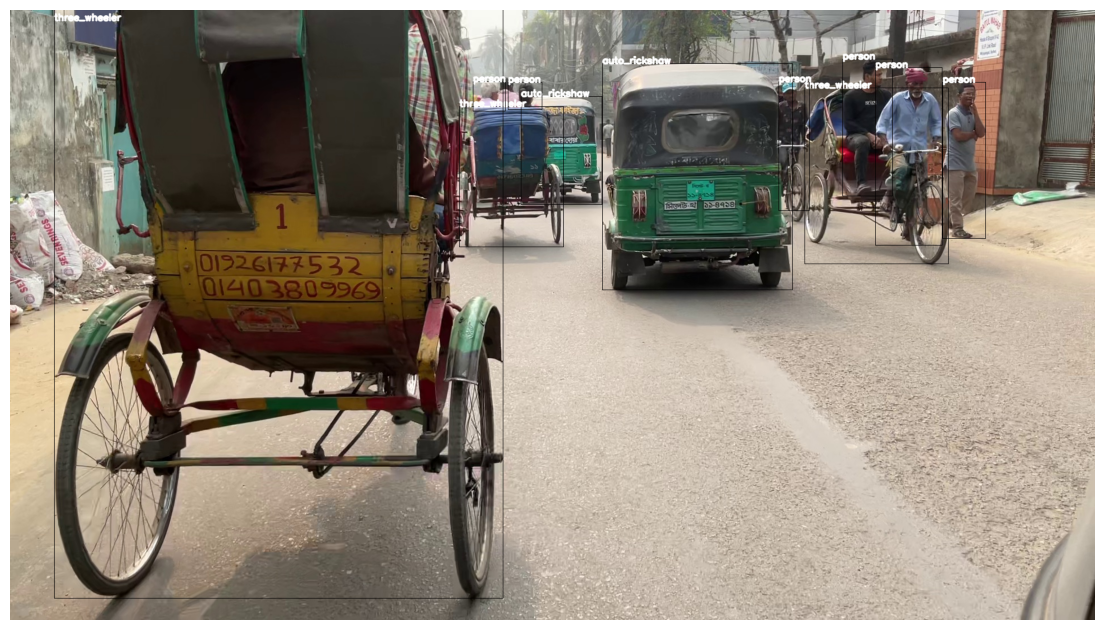


Image: khulna4_7680.jpg
Label: khulna4_7680.txt


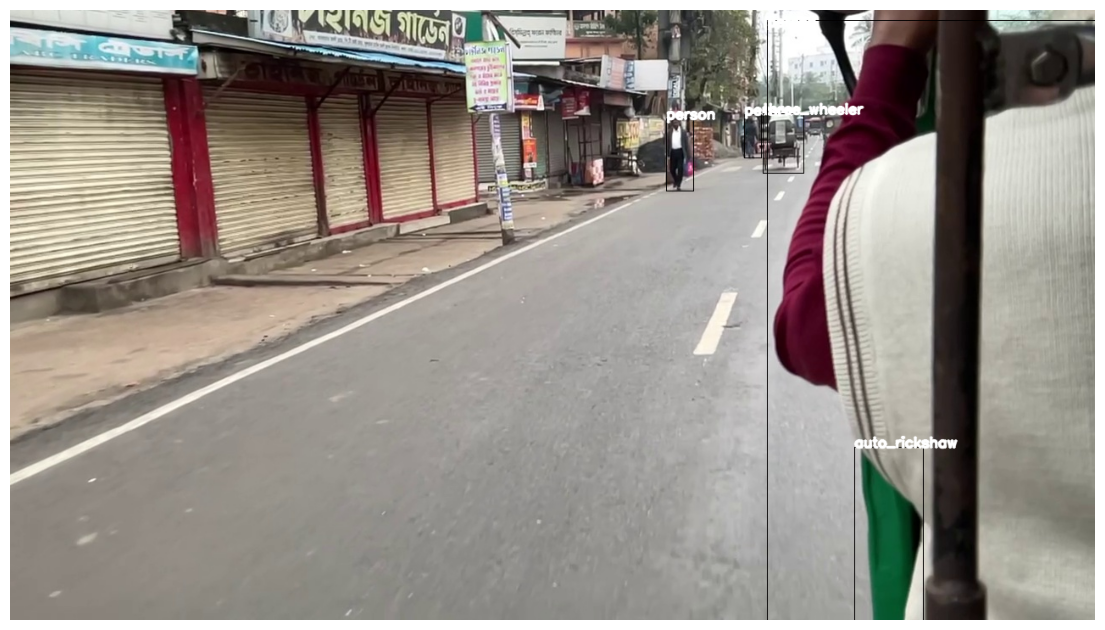

In [47]:
# Cell 22 — Optional: display 6 random training images
sample_n = min(6, len(train_images))
sample_images = random.sample(train_images, sample_n)

for img in sample_images:
    lbl = OUTPUT / "labels" / "train" / f"{img.stem}.txt"
    print("\n", "=" * 100)
    print("Image:", img.name)
    print("Label:", lbl.name)
    show_yolo_image(img, lbl)

# YOLOv8 training

The first experiment uses the paper's listed settings:

- epochs = 10
- imgsz = 416
- batch = 64
- optimizer = Adam
- learning rate = 0.001
- weight decay = 1e-4

This notebook uses **YOLOv8s** because the paper does not state which YOLOv8 model size was used.

In [48]:
# Cell 23 — Install Ultralytics
!pip install -q ultralytics

In [49]:
# Cell 24 — Check Ultralytics version
import ultralytics
from ultralytics import YOLO

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.136
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [50]:
# Cell 25 — Train YOLOv8s for 10 epochs
# If batch=64 causes CUDA out-of-memory, change only batch to 32 or 16
# and document that change in your report.

model_v8 = YOLO("yolov8s.pt")

results_v8 = model_v8.train(
    data=str(YAML_PATH),
    epochs=10,
    imgsz=416,
    batch=64,
    optimizer="Adam",
    lr0=0.001,
    weight_decay=1e-4,
    device=0 if torch.cuda.is_available() else "cpu",
    seed=SEED,
    deterministic=True,
    project="/kaggle/working/results",
    name="YOLOv8s_BadODD_10epochs",
    plots=True,
    verbose=True,
)

Ultralytics 8.4.136 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/badodd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s_BadODD_10epochs, nbs=64, 

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/10      7.26G      1.465      1.191      1.116        105        416: 100% ━━━━━━━━━━━━ 94/94 1.9it/s 50.2s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.6it/s 10.1s.6s
                   all       2032      16369      0.551      0.321       0.34      0.194

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10      7.27G      1.487      1.182      1.128        149        416: 100% ━━━━━━━━━━━━ 94/94 1.9it/s 50.1s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.6it/s 10.0s.6s
                   all       2032      16369      0.676      0.246      0.314      0.178

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/10      7.27G      1.468       1.13      1.121         88        416: 100% ━━━━━━━━━━━━ 94/94 1.9it/s 49.5s0.3ss
                 Class     Images  I

In [51]:
# Cell 26 — Load best YOLOv8 weights
V8_BEST = Path("/kaggle/working/results/YOLOv8s_BadODD_10epochs/weights/best.pt")

if not V8_BEST.exists():
    raise FileNotFoundError(f"YOLOv8 best weights not found: {V8_BEST}")

best_v8 = YOLO(str(V8_BEST))
print("Loaded:", V8_BEST)

Loaded: /kaggle/working/results/YOLOv8s_BadODD_10epochs/weights/best.pt


In [52]:
# Cell 27 — Evaluate YOLOv8 on the TEST set
metrics_v8 = best_v8.val(
    data=str(YAML_PATH),
    split="test",
    imgsz=416,
    batch=64,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
)

v8_summary = {
    "model": "YOLOv8s",
    "epochs": 10,
    "precision": float(metrics_v8.box.mp),
    "recall": float(metrics_v8.box.mr),
    "mAP50": float(metrics_v8.box.map50),
    "mAP50_95": float(metrics_v8.box.map),
}

print(v8_summary)

Ultralytics 8.4.136 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,130,615 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2227.9±1064.6 MB/s, size: 382.6 KB)
val: Scanning /kaggle/working/badodd_yolo/labels/test... 2032 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2032/2032 1.2Kit/s 1.7s0.1s
val: New cache created: /kaggle/working/badodd_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.0it/s 15.9s0.4s
                   all       2032      16149      0.683      0.473       0.51      0.305
         auto_rickshaw       1379       3513      0.761       0.79      0.812      0.564
               bicycle        232        256      0.648      0.328      0.341      0.153
                   bus        376        620      0.635      0.589      0.624      0.412
                   car        762       1236    

In [53]:
# Cell 28 — Run YOLOv8 prediction on one random test image
test_images = [
    p for p in (OUTPUT / "images" / "test").iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

sample_test_image = random.choice(test_images)

print("Predicting:", sample_test_image)

prediction_v8 = best_v8.predict(
    source=str(sample_test_image),
    conf=0.25,
    imgsz=416,
    save=True,
    project="/kaggle/working/predictions",
    name="yolov8_test_prediction",
)

Predicting: /kaggle/working/badodd_yolo/images/test/chuadanga_sirajganj1_6180.jpg

image 1/1 /kaggle/working/badodd_yolo/images/test/chuadanga_sirajganj1_6180.jpg: 416x256 4 persons, 5 three_wheelers, 7.7ms
Speed: 1.2ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 256)
Results saved to /kaggle/working/predictions/yolov8_test_prediction


# YOLOv5 training

This notebook uses the official Ultralytics YOLOv5 repository.

The paper reports the same listed hyperparameters for YOLOv5:
batch 64, learning rate 0.001, 10 epochs, Adam, weight decay 1e-4, image size 416.

This notebook uses **YOLOv5s** because the paper does not state which YOLOv5 model size was used.

In [54]:
# Cell 29 — Clone official YOLOv5 repository
YOLOV5_DIR = Path("/kaggle/working/yolov5")

if YOLOV5_DIR.exists():
    shutil.rmtree(YOLOV5_DIR)

!git clone -q https://github.com/ultralytics/yolov5.git /kaggle/working/yolov5

print("YOLOv5 cloned to:", YOLOV5_DIR)

YOLOv5 cloned to: /kaggle/working/yolov5


In [55]:
# Cell 30 — Install YOLOv5 requirements
!pip install -qr /kaggle/working/yolov5/requirements.txt

In [56]:
# Cell 31 — Create YOLOv5 hyperparameter file matching paper values
import yaml

hyp_candidates = [
    Path("/kaggle/working/yolov5/data/hyps/hyp.scratch-low.yaml"),
    Path("/kaggle/working/yolov5/data/hyps/hyp.scratch.yaml"),
]

original_hyp = next((p for p in hyp_candidates if p.exists()), None)

if original_hyp is None:
    raise FileNotFoundError("Could not find a YOLOv5 hyperparameter YAML file.")

with open(original_hyp) as f:
    hyp = yaml.safe_load(f)

hyp["lr0"] = 0.001
hyp["weight_decay"] = 1e-4

CUSTOM_HYP = Path("/kaggle/working/yolov5_badodd_hyp.yaml")

with open(CUSTOM_HYP, "w") as f:
    yaml.safe_dump(hyp, f, sort_keys=False)

print("Base hyp:", original_hyp)
print("Custom hyp:", CUSTOM_HYP)
print("lr0 =", hyp["lr0"])
print("weight_decay =", hyp["weight_decay"])

Base hyp: /kaggle/working/yolov5/data/hyps/hyp.scratch-low.yaml
Custom hyp: /kaggle/working/yolov5_badodd_hyp.yaml
lr0 = 0.001
weight_decay = 0.0001


In [57]:
# Cell 32 — Train YOLOv5s for 10 epochs
# If batch 64 causes CUDA OOM, reduce to 32 or 16 and document it.

!python /kaggle/working/yolov5/train.py     --weights yolov5s.pt     --data /kaggle/working/badodd.yaml     --img 416     --batch 64     --epochs 10     --optimizer Adam     --hyp /kaggle/working/yolov5_badodd_hyp.yaml     --device 0     --project /kaggle/working/results_yolov5     --name YOLOv5s_BadODD_10epochs     --exist-ok

WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: auth token too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/kaggle/working/badodd.yaml, hyp=/kaggle/working/yolov5_badodd_hyp.yaml, epochs=10, batch_size=64, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=yolov5/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=Adam, sync_bn=False, workers=8, project=/kaggle/working/results_yolo

In [58]:
# Cell 33 — Find YOLOv5 best weights
V5_BEST = Path(
    "/kaggle/working/results_yolov5/YOLOv5s_BadODD_10epochs/weights/best.pt"
)

print("YOLOv5 best weights:", V5_BEST)
print("Exists:", V5_BEST.exists())

YOLOv5 best weights: /kaggle/working/results_yolov5/YOLOv5s_BadODD_10epochs/weights/best.pt
Exists: True


In [59]:
# Cell 34 — Evaluate YOLOv5 on the TEST set
# YOLOv5 val.py prints Precision, Recall, mAP@0.5, and mAP@0.5:0.95.

!python /kaggle/working/yolov5/val.py     --weights /kaggle/working/results_yolov5/YOLOv5s_BadODD_10epochs/weights/best.pt     --data /kaggle/working/badodd.yaml     --img 416     --batch-size 64     --task test     --device 0     --project /kaggle/working/results_yolov5_test     --name YOLOv5s_BadODD_test     --exist-ok

val: data=/kaggle/working/badodd.yaml, weights=['/kaggle/working/results_yolov5/YOLOv5s_BadODD_10epochs/weights/best.pt'], batch_size=64, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/kaggle/working/results_yolov5_test, name=YOLOv5s_BadODD_test, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-551-g2b1bdcd0 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)

Fusing layers... 
Model summary: 68 layers, 7,045,186 parameters, 0 gradients, 15.9 GFLOPs
test: Scanning /kaggle/working/badodd_yolo/labels/test... 2032 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2032/2032 4.0Kit/s 0.5s0.1s
test: New cache created: /kaggle/working/badodd_yolo/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 32/32 1.1it/s 28.3s0.7ss
                   

# Optional epoch experiments

Do this **after** the 10-epoch reproduction.

Good follow-up experiments:
- 30 epochs
- 50 epochs
- 100 epochs

Keep the other settings unchanged so the effect of epoch count is easier to interpret.

In [60]:
# Cell 35 — Helper function for YOLOv8 epoch experiments
def train_v8_epoch_experiment(epochs, batch=64):
    model = YOLO("yolov8s.pt")

    return model.train(
        data=str(YAML_PATH),
        epochs=epochs,
        imgsz=416,
        batch=batch,
        optimizer="Adam",
        lr0=0.001,
        weight_decay=1e-4,
        device=0 if torch.cuda.is_available() else "cpu",
        seed=SEED,
        deterministic=True,
        project="/kaggle/working/epoch_experiments",
        name=f"YOLOv8s_E{epochs}",
        plots=True,
        verbose=True,
    )

print("Example:")
print("train_v8_epoch_experiment(30)")
print("train_v8_epoch_experiment(50)")
print("train_v8_epoch_experiment(100)")

Example:
train_v8_epoch_experiment(30)
train_v8_epoch_experiment(50)
train_v8_epoch_experiment(100)


In [61]:
# Cell 36 — OPTIONAL: uncomment one experiment at a time
# result_30 = train_v8_epoch_experiment(30)
# result_50 = train_v8_epoch_experiment(50)
# result_100 = train_v8_epoch_experiment(100)

In [62]:
# Cell 37 — Show important output folders
important_paths = [
    OUTPUT,
    YAML_PATH,
    Path("/kaggle/working/results"),
    Path("/kaggle/working/results_yolov5"),
    Path("/kaggle/working/results_yolov5_test"),
    Path("/kaggle/working/predictions"),
    Path("/kaggle/working/epoch_experiments"),
]

for p in important_paths:
    print(f"{str(p):70s} exists={p.exists()}")

/kaggle/working/badodd_yolo                                            exists=True
/kaggle/working/badodd.yaml                                            exists=True
/kaggle/working/results                                                exists=True
/kaggle/working/results_yolov5                                         exists=True
/kaggle/working/results_yolov5_test                                    exists=True
/kaggle/working/predictions                                            exists=True
/kaggle/working/epoch_experiments                                      exists=False


# What to save from Kaggle after training

For your report/thesis, save:

1. `best.pt` for YOLOv8
2. `best.pt` for YOLOv5
3. `results.csv` / training curves
4. confusion matrix
5. precision-recall curve
6. F1 curve
7. example predictions
8. test-set Precision
9. test-set Recall
10. test-set mAP@0.50
11. test-set mAP@0.50:0.95
12. all software/library versions
13. any change you made to batch size because of GPU memory

Do not call mAP@0.50:0.95 simply "accuracy". Object detection metrics are different from ordinary classification accuracy.